In [1]:
import numpy as np
from scipy.special import gamma, zeta, eval_hermite, factorial
import matplotlib.pyplot as plt

In [2]:
def sech(x):
    return 1 / np.cosh(x)

In [3]:
_kappa_cache = {}

def _N_m(m, kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

def _compute_Z_m(m, A_coeffs, kappa):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = _N_m(Nj_index, kappa)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1 / Z

def _get_A_m(m, kappa):
    if kappa not in _kappa_cache:
        _kappa_cache[kappa] = {
            "A_list": {0: [1.0]},
            "Z_dict": {0: kappa / 4},
        }

    A_list = _kappa_cache[kappa]["A_list"]
    Z_dict = _kappa_cache[kappa]["Z_dict"]

    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = _get_A_m(lower_m, kappa)

        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = _N_m(m - (i + j), kappa)
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = _compute_Z_m(m, A_m_coeffs, kappa)
    Z_dict[m] = Z_m
    A_list[m] = A_m_coeffs
    return A_m_coeffs

def xi_m(t, m, kappa):
    A_coeffs = _get_A_m(m, kappa)
    Zm = _kappa_cache[kappa]["Z_dict"][m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

In [4]:
from mpmath import *
def gamma_t(time, const, plot=0, form=0):
    center = (time[0] + time[-1]) / 2
    def Li_2(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(2, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_3(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(3, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_4(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(4, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_5(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(5, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_6(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(6, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    if form==0:
        top = (const/2)/(np.cosh(const*(time-center)))**2
        bottom = 1-(1/2)*(np.tanh(const*(time-center))-np.tanh(const*(time[0]-center)))
    elif form==1:                                                      
        top = (6*const**3/np.pi**2)*(time-center)**2/(np.cosh(const*(time-center)))**2
        def f(t):
            return 6 * (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t))) / np.pi**2
        bottom = 1-(f(const*(time-center))-f(const*(time[0]-center)))
    elif form==2:                                                    
        top = (45*const**5/2/np.pi**4) * ((time-center)**2 - (np.pi/const)**2/12)**2/ (np.cosh(const * (time - center)))**2
        def f(t):
            f_2 = 6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1)
            f_1 = -np.pi**2 * (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t))) /6
            f_0 = np.pi**4*np.tanh(t)/144
            return 45*(f_2 + f_1 + f_0)/2/np.pi**4
        bottom = 1 - (f(const * (time - center)) - f(const * (time[0] - center)))
    elif form==3:
        top = (350*const**7/9/np.pi**6) * ((time-center)**3 - 7*(np.pi/const)**2/20*(time-center))**2/ (np.cosh(const * (time - center)))**2
        def f(t):
            f_3 = 15*t**4*Li_2(t) + 30*t**3*Li_3(t) + 45*t**2*Li_4(t) + 45*t*Li_5(t) + 45/2*Li_6(t) - t**6*(1 - np.tanh(t)) - 6*t**5*np.log(np.exp(-2 * t) + 1)
            f_2 = -7*np.pi**2*(6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1))/10
            f_1 =  (7*np.pi**2/20)**2* (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t)))
            return 350*(f_3 + f_2 + f_1)/9/np.pi**6
        bottom = 1 - (f(const * (time - center)) - f(const * (time[0] - center)))
    if plot:
        plt.figure(figsize=(6,2))
        plt.plot(time, top/bottom/2/np.pi)
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.show()
    return top/bottom/2/np.pi

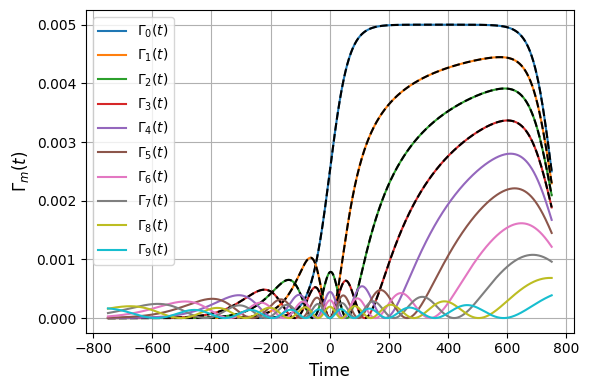

In [5]:
from scipy.integrate import cumulative_trapezoid 
from scipy.integrate import quad

m = 0
t0 = 0
t1 = 1500
N = 1500
t = np.linspace(t0, t1, N)
center = (t0+t1)/2
kappa =  2.5e-3*2*np.pi*2

plt.figure(figsize=(6, 4))
for m in range(10):
    ## cumulative_trapezoid
    xi_vals = np.array([xi_m(ti, m, kappa) for ti in t-center])
    abs_sq = np.abs(xi_vals)**2
    
    integral = cumulative_trapezoid(abs_sq, t-center, initial=0)
    denominator = 1 - integral
    denominator[denominator <= 1e-12] = np.nan
    Gamma_num = abs_sq / denominator / (2 * np.pi)
    plt.plot(t-center, Gamma_num, linestyle='-', label=fr"$\Gamma_{{{m}}}(t)$")

    ## quad
    # Gamma_list = []
    # for ti in t:
    #     integral, _ = quad(lambda tau: np.abs(xi_m(tau, m, kappa))**2, t0, ti)
    #     denominator = 1 - integral
    #     if denominator <= 1e-12:
    #         Gamma_list.append(np.nan)
    #     else:
    #         abs_sq = np.abs(xi_m(ti, m, kappa))**2
    #         Gamma_list.append(abs_sq / denominator / (2 * np.pi))
    # Gamma_num = np.array(Gamma_list)

    # plt.plot(t, Gamma_num, linestyle='-', label=fr"$\Gamma_{{{m}}}(t)$")
    if m <= 3:
        Gamma_ana = gamma_t(t, kappa / 2, form=m)
        plt.plot(t-center, Gamma_ana, linestyle='--', color="black")

plt.xlabel("Time", fontsize=12)
plt.ylabel(r"$\Gamma_m(t)$", fontsize=12)
plt.grid(True)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

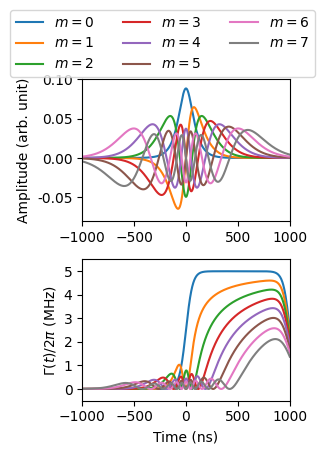

In [ ]:
from matplotlib.ticker import FormatStrFormatter
duration = 2000
t_vals = np.linspace(-duration/2, duration/2, duration)

m = 0
t0 = -1000
t1 = 1000
N = 2000
t = np.linspace(t0, t1, N)
center = 0

fig, axes = plt.subplots(2, 1, figsize=(3.2, 4))

for m in range(8):
    y_vals = [xi_m(t, m, kappa) for t in t_vals]
    axes[0].plot(t_vals, y_vals, label=f'$m={m}$')

    xi_vals = np.array([xi_m(ti, m, kappa) for ti in t-center])
    abs_sq = np.abs(xi_vals)**2
    
    integral = cumulative_trapezoid(abs_sq, t-center, initial=0)
    denominator = 1 - integral
    # denominator[denominator <= 1e-12] = np.nan
    Gamma_num = abs_sq / denominator / (2 * np.pi)
    axes[1].plot(t-center, Gamma_num*1000, linestyle='-')

    # ## quad
    # Gamma_list = []
    # for ti in t:
    #     integral, _ = quad(lambda tau: np.abs(xi_m(tau, m, kappa))**2, t0, ti)
    #     denominator = 1 - integral
    #     if denominator <= 1e-14:
    #         Gamma_list.append(np.nan)
    #     else:
    #         abs_sq = np.abs(xi_m(ti, m, kappa))**2
    #         Gamma_list.append(abs_sq / denominator / (2 * np.pi))
    # Gamma_num = np.array(Gamma_list)
    # axes[1].plot(t, Gamma_num, linestyle='-', label=fr"$\Gamma_{{{m}}}(t)$")

    axes[0].set_ylim(-0.08, 0.1)
    axes[0].set_xlim(-1000, 1000)
    axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    axes[0].set_ylabel('Amplitude (arb. unit)')
    axes[1].set_ylim(-0.5, 5.5)
    axes[1].set_xlim(-1000, 1000)
    axes[1].set_ylabel(r'$\Gamma(t)/2\pi$ (MHz)')

plt.xlabel('Time (ns)')

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.14), ncol=3)
# plt.grid(True)
plt.tight_layout()
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

# plt.savefig("Fig5ab.pdf", bbox_inches='tight')
plt.show()

In [7]:
def fourier_tr_padding_centered(x, y, center_x, n_padding=100):
    N = len(y)
    
    center_idx = np.argmin(np.abs(x - center_x))
    
    half_len = min(center_idx, N - center_idx - 1)
    y_centered = y[center_idx - half_len : center_idx + half_len + 1]
    
    pad_len = len(y_centered) * (n_padding - 1)
    pad_left = pad_len // 2
    pad_right = pad_len - pad_left
    y_pad = np.concatenate([np.zeros(pad_left, dtype=complex),
                            y_centered,
                            np.zeros(pad_right, dtype=complex)])
    y_pad_shifted = np.fft.ifftshift(y_pad)
    data_fft = np.fft.fft(y_pad_shifted)
    freq_fft = np.fft.fftfreq(len(y_pad), x[1] - x[0])
    
    data_fft = np.fft.fftshift(data_fft)
    freq_fft = np.fft.fftshift(freq_fft)
    
    return freq_fft, data_fft

In [8]:
def compute_bandwidth(freq, fft_data, ratio=0.99):
    """freq [GHz], fft_data (complex) -> bandwidth that contains ratio of power"""
    power = np.abs(fft_data)**2
    power /= np.sum(power)
    
    cdf = np.cumsum(power)
    cdf /= cdf[-1]
    
    lower_idx = np.where(cdf >= (1 - ratio) / 2)[0][0]
    upper_idx = np.where(cdf >= 1 - (1 - ratio) / 2)[0][0]
    
    return freq[upper_idx] - freq[lower_idx]

In [12]:
from scipy.signal import argrelextrema
from scipy import signal
Fs = 1e9  # 1 GSa/s
fc = 400e6  # 400 MHz BW
sos = signal.butter(3, fc/(Fs/2), btype='low', output='sos')

def xi_from_Gamma(Gamma, t_ns, apply_sign=None):

    Gamma = np.array(Gamma, dtype=float)
    t_ns = np.array(t_ns, dtype=float)

    Gamma_per_ns = Gamma * 1e-3*(2 * np.pi)
    cumG = cumulative_trapezoid(Gamma_per_ns, t_ns, initial=0.0) 
    mag = np.sqrt(np.maximum(Gamma_per_ns, 0.0)) * np.exp(-0.5 * cumG)
    if apply_sign is None:
        return mag.astype(complex)
    else:
        s = np.array(apply_sign, dtype=float)
        s[s == 0] = 1.0
        return (mag * s).astype(complex)


def overlap_and_fidelity(xi1, xi2, t_ns):
    num = np.trapezoid(np.conjugate(xi1) * xi2, t_ns)
    n1 = np.trapezoid(np.abs(xi1)**2, t_ns)
    n2 = np.trapezoid(np.abs(xi2)**2, t_ns)
    if n1 <= 0 or n2 <= 0:
        return 0+0j, 0.0
    O = num / np.sqrt(n1 * n2)
    return O, np.abs(O)**2

Mode m=0: overlap = 0.997591+0.000000j, fidelity = 9.951873e-01
Mode m=1: overlap = 0.997296+0.000000j, fidelity = 9.945992e-01
Mode m=2: overlap = 0.996994+0.000000j, fidelity = 9.939968e-01
Mode m=3: overlap = 0.996757+0.000000j, fidelity = 9.935246e-01


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


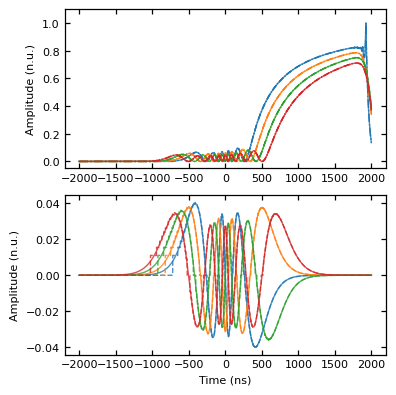

In [13]:
m = 0
t0 = -2000
t1 = 2000
N = 4000
t = np.linspace(t0, t1, N)
center = 0

# DAC settings
n_bits = 8
n_steps = 2**n_bits
V_DAC_step = 1 / (n_steps - 1)

dt = t[1] - t[0]  # ns

fig, axes = plt.subplots(2, 1, figsize=(4, 4))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

Gamma_all = []
sign_arrays = []
for m in range(4):
    m = m + 5
    xi_vals = np.array([xi_m(ti, m, kappa) for ti in t-center])
    abs_sq = np.abs(xi_vals)**2
    integral = cumulative_trapezoid(abs_sq, t-center, initial=0)
    denominator = 1 - integral
    Gamma_num = np.array(abs_sq / denominator / (2 * np.pi) * 1000, dtype=float)

    
    minima_raw = argrelextrema(Gamma_num, np.less)[0]
    threshold = 0.05 * np.max(Gamma_num)
    minima = [idx for idx in minima_raw if Gamma_num[idx] < threshold]
    minima = np.array(minima)
    drive_pulse = Gamma_num.copy()
    sign = 1.0
    last_idx = 0
    for idx in minima:
        drive_pulse[last_idx:idx] = sign * Gamma_num[last_idx:idx]
        sign *= -1.0
        last_idx = idx
    drive_pulse[last_idx:] = sign * Gamma_num[last_idx:]
    sign_array = np.sign(drive_pulse)
    sign_array[sign_array == 0] = 1.0

    Gamma_all.append(Gamma_num)
    sign_arrays.append(sign_array)

global_maxG = np.max(np.abs(Gamma_all[0]))
for m, (Gamma_num, sign_array) in enumerate(zip(Gamma_all, sign_arrays)):
    Gamma_abs = np.abs(Gamma_num)

    if global_maxG == 0:
        Gamma_q = Gamma_abs.copy()
    else:
        drive_norm = Gamma_abs / global_maxG
        drive_norm_float = np.array(drive_norm, dtype=float)
        quant_levels = np.round(drive_norm_float * (n_steps - 1)) / (n_steps - 1)
        Gamma_q = quant_levels * global_maxG
    
    Gamma_q_filtered = signal.sosfilt(sos, Gamma_q)

    # xi
    xi_ideal = xi_from_Gamma(np.abs(Gamma_num), t-center, apply_sign=sign_array)
    xi_dac   = xi_from_Gamma(Gamma_q, t-center, apply_sign=sign_array)

    O, fid = overlap_and_fidelity(xi_ideal, xi_dac, t-center)
    print(f"Mode m={m}: overlap = {O:.6f}, fidelity = {fid:.6e}")

    if global_maxG > 0:
        axes[0].plot(t-center, Gamma_abs/global_maxG, color=colors[m % len(colors)], alpha=0.8)
        axes[0].step(t-center, Gamma_q/global_maxG, where='mid', color=colors[m % len(colors)], linestyle='-.')
        # axes[0].step(t-center, Gamma_q_filtered/global_maxG, where='mid', color=colors[m % len(colors)], linestyle='--')
    axes[1].plot(t-center, xi_ideal, color=colors[m % len(colors)], alpha=0.8, label=f"xi_ideal m={m}")
    axes[1].plot(t-center, xi_dac, '--', color=colors[m % len(colors)], alpha=0.8, label=f"xi_dac m={m}")
    axes[0].set_ylabel("Amplitude (n.u.)")
    axes[0].set_ylim(-0.05, 1.1)
    axes[1].set_ylabel("Amplitude (n.u.)")
    axes[1].set_xlabel("Time (ns)")

plt.tight_layout()
plt.show()

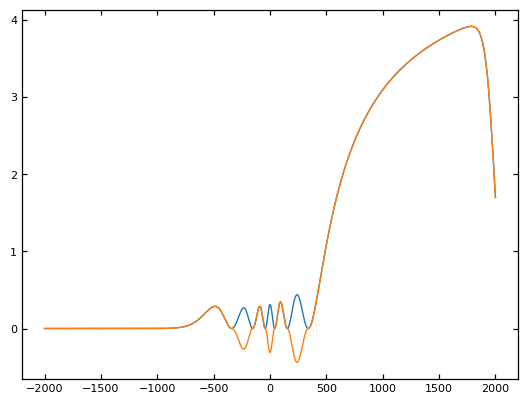

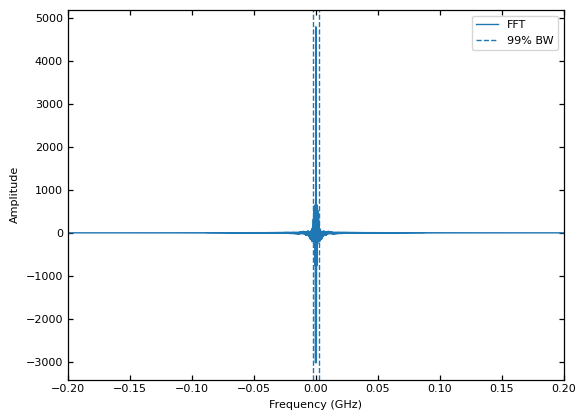

Bandwidth (99% power) = 0.005 GHz


In [14]:
plt.plot(t-center, Gamma_all[1])
s = np.array(sign_arrays[1], dtype=float)
s[s == 0] = 1.0
plt.plot(t-center, Gamma_all[1] * s)
plt.show()

wave = Gamma_all[1] * s
freq, fft_data = fourier_tr_padding_centered(
    t-center,
    wave,
    center_x=0,
    n_padding=20
)

plt.figure()
plt.plot(freq, fft_data, label="FFT")

f0 = freq[np.argmax(fft_data)]

BW = compute_bandwidth(freq, fft_data, ratio=0.99)

plt.axvline(f0 + BW/2, linestyle='--', label="99% BW")
plt.axvline(f0 - BW/2, linestyle='--')

plt.xlabel("Frequency (GHz)")
plt.ylabel("Amplitude")
plt.xlim(-0.2, 0.2)
plt.legend()
plt.show()

print("Bandwidth (99% power) = {:.3f} GHz".format(BW))


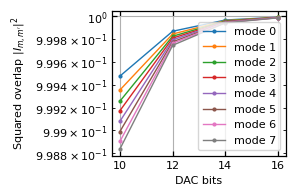

In [15]:
from scipy.ndimage import gaussian_filter1d

t0, t1, N = -2000, 2000, 4000
t = np.linspace(t0, t1, N)
center = 0

n_bits_list = [10, 12, 14, 16]
n_modes = 8 
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

Gamma_all = []
sign_arrays = []
for m in range(n_modes):
    xi_vals = np.array([xi_m(ti, m, kappa) for ti in t-center])
    abs_sq = np.abs(xi_vals)**2
    integral = cumulative_trapezoid(abs_sq, t-center, initial=0)
    denominator = 1 - integral
    Gamma_num = np.array(abs_sq / denominator / (2 * np.pi) * 1000, dtype=float)

    minima = argrelextrema(Gamma_num, np.less)[0]
    drive_pulse = Gamma_num.copy()
    sign = 1.0
    last_idx = 0
    for idx in minima:
        drive_pulse[last_idx:idx] = sign * Gamma_num[last_idx:idx]
        sign *= -1.0
        last_idx = idx
    drive_pulse[last_idx:] = sign * Gamma_num[last_idx:]
    sign_array = np.sign(drive_pulse)
    sign_array[sign_array == 0] = 1.0

    Gamma_all.append(Gamma_num)
    sign_arrays.append(sign_array)

global_maxG = np.max(np.abs(Gamma_all[0]))
fidelity_matrix = np.zeros((n_modes, len(n_bits_list)))

for i, n_bits in enumerate(n_bits_list):
    n_steps = 2**n_bits
    for m, (Gamma_num, sign_array) in enumerate(zip(Gamma_all, sign_arrays)):
        Gamma_abs = np.abs(Gamma_num)
        if global_maxG == 0:
            Gamma_q = Gamma_abs.copy()
        else:
            drive_norm = Gamma_abs / global_maxG
            quant_levels = np.round(drive_norm * (n_steps - 1)) / (n_steps - 1)
            Gamma_q = quant_levels * global_maxG

        xi_ideal = xi_from_Gamma(Gamma_abs, t-center, apply_sign=sign_array)
        xi_dac   = xi_from_Gamma(Gamma_q, t-center, apply_sign=sign_array)

        O, fid = overlap_and_fidelity(xi_ideal, xi_dac, t-center)
        fidelity_matrix[m, i] = fid

plt.figure(figsize=(3,2))
for m in range(n_modes):
    plt.plot(n_bits_list, fidelity_matrix[m], '-o', color=colors[m % len(colors)], label=f"mode {m}")
plt.xlabel("DAC bits")
plt.ylabel(r"Squared overlap $|I_{m, m^{\prime}}|^2$")
# plt.title("Fidelity vs DAC resolution")
# plt.ylim(0, 1.05)
plt.yscale('log') 
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


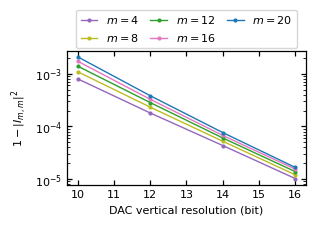

In [ ]:
t0, t1, N = -3000, 3000, 6000
t = np.linspace(t0, t1, N)
center = 0

n_bits_list = [10, 12, 14, 16]
mode_list = [4, 8, 12, 16, 20]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

Gamma_all = []
sign_arrays = []

for m in mode_list:
    
    xi_vals = np.array([xi_m(ti, m, kappa) for ti in t-center])
    abs_sq = np.abs(xi_vals)**2
    integral = cumulative_trapezoid(abs_sq, t-center, initial=0)
    denominator = 1 - integral
    Gamma_num = np.array(abs_sq / denominator / (2 * np.pi) * 1000, dtype=float)  # MHz

    minima = argrelextrema(Gamma_num, np.less)[0]
    drive_pulse = Gamma_num.copy()
    sign = 1.0
    last_idx = 0
    for idx in minima:
        drive_pulse[last_idx:idx] = sign * Gamma_num[last_idx:idx]
        sign *= -1.0
        last_idx = idx
    drive_pulse[last_idx:] = sign * Gamma_num[last_idx:]
    sign_array = np.sign(drive_pulse)
    sign_array[sign_array == 0] = 1.0

    Gamma_all.append(Gamma_num)
    sign_arrays.append(sign_array)

global_maxG = max(np.max(np.abs(G)) for G in Gamma_all if np.max(np.abs(G)) > 0)


squared_overlap_matrix = np.zeros((len(mode_list), len(n_bits_list)))

for i, n_bits in enumerate(n_bits_list):
    n_steps = 2**n_bits
    for m_idx, (Gamma_num, sign_array) in enumerate(zip(Gamma_all, sign_arrays)):
        Gamma_abs = np.abs(Gamma_num)
        if global_maxG == 0:
            Gamma_q = Gamma_abs.copy()
        else:
            drive_norm = Gamma_abs / global_maxG
            quant_levels = np.round(drive_norm * (n_steps - 1)) / (n_steps - 1)
            Gamma_q = quant_levels * global_maxG

        xi_ideal = xi_from_Gamma(Gamma_abs, t-center, apply_sign=sign_array)
        xi_dac   = xi_from_Gamma(Gamma_q, t-center, apply_sign=sign_array)

        _, fid = overlap_and_fidelity(xi_ideal, xi_dac, t-center)
        squared_overlap_matrix[m_idx, i] = fid
def mode_to_color_idx(m, mode_list):
    sorted_modes = sorted(mode_list)
    return sorted_modes.index(m) % len(colors)

plt.figure(figsize=(3.2, 2.5))
for m_idx, m in enumerate(mode_list):
    color_idx = m % len(colors)
    plt.plot(n_bits_list, 1-squared_overlap_matrix[m_idx], '-o',
             color=colors[color_idx], label=rf"$m={m}$")
plt.xlabel("DAC vertical resolution (bit)")
plt.ylabel(r"$1 - |I_{m, m}|^2$", x=0.1)
plt.yscale('log')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.35), ncol=3,handlelength=1.5, 
            columnspacing=1 )
plt.tight_layout()
# plt.savefig("Fig5c.pdf", bbox_inches='tight')
plt.show()